<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/iportfolio/images/logos/kuleuven.png/@@images/image-800-e89431243530c6a800aa1186b9f6891b.png" width=auto height=200px align=left>
</div>

# KUL H02A5a Computer Vision — Group Assignment 1

**Team 27** | Fosteris Emmanouil · Paschalidis Marios · Greiner Luc · Reyes Salazar Jose · Digenis Stefanos

---

### Notebook structure

| Section | Content |
|---------|---------|
| 0 | Data loading & preprocessing |
| 1 | Feature representations (HOG, PCA) |
| 2 | Evaluation metrics |
| 3 | Classifiers |
| 4 | Experiments |
| 5 | Best results & submission |
| 6 | Discussion |

> **Helper modules** (imported below):
> - `face_detection.py` — HAARPreprocessor, DNNFaceDetector
> - `preprocessing.py`  — face_to_gray, HOG/PCA helpers, train/val split
> - `visualize.py`       — all plotting functions
> - `annotate.py`       — all data annotations functions


## Imports

In [1]:
import os, math, shutil, threading
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from skimage.feature import hog

# Local modules
from face_detection  import DNNFaceDetector, HAARPreprocessor, run_preprocessing
from preprocessing   import (face_to_gray, convert_crops_to_gray, extract_hog_batch,
                              flatten_images, normalize_per_image, apply_pca,
                              get_train_val_split, summarize_dataset, save_crops)
from visualize       import (plot_class_distribution, plot_class_grid, plot_face_debug,
                              plot_image_sequence, plot_hog_features, plot_tsne,
                              plot_eigenfaces, plot_explained_variance,
                              plot_pca_reconstruction, plot_pca_scatter,
                              plot_validation_images, plot_confusion_matrix)


---
# 0. Data Loading & Preprocessing


## 0.1 Load data

The training set is intentionally small (80 images) relative to the test set (1816 images).
This mirrors a real-world scenario: a model trained on a handful of labelled examples must
generalise to daily production traffic.

The dataset is a subset of the [VGG Face Dataset](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/)
and contains four people:

| Person | Class label | # images |
|--------|-------------|----------|
| Jesse Eisenberg | 1 | 30 |
| Mila Kunis | 2 | 30 |
| Michael Cera (Jesse lookalike) | 0 | 10 |
| Sarah Hyland (Mila lookalike) | 0 | 10 |

Michael and Sarah are intentionally included to test whether the classifier can distinguish
the target person from someone who looks similar.


In [ ]:
train = pd.read_csv('datasets/train_set.csv', index_col=0)
train.index = train.index.rename('id')

test = pd.read_csv('datasets/test_set.csv', index_col=0)
test.index = test.index.rename('id')

# Load raw images as RGB numpy arrays
train['img'] = [cv2.cvtColor(np.load(f'datasets/train/train_{i}.npy', allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in train.iterrows()]
test['img']  = [cv2.cvtColor(np.load(f'datasets/test/test_{i}.npy',  allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in test.iterrows()]

print(f"Training set : {len(train)} images")
print(f"Test set     : {len(test)}  images")
train.head(1)

## 0.2 Exploratory analysis

Before preprocessing, we inspect the class distribution and basic image statistics.
This confirms the class imbalance (Jesse/Mila have 3× more images than the lookalikes)
and checks whether images have consistent dimensions.


In [ ]:
# Class distribution
print(train.groupby('name').agg({'img': 'count', 'class': 'max'}))
plot_class_distribution(train['class'].values, class_names={0:'Michael/Sarah',1:'Jesse',2:'Mila'})

In [ ]:
# Image size statistics — check for dimension variation before choosing FACE_SIZE
train['h'] = train['img'].apply(lambda x: x.shape[0])
train['w'] = train['img'].apply(lambda x: x.shape[1])
train['aspect'] = train['w'] / train['h']
train[['h', 'w', 'aspect']].describe().round(2)

## 0.3 Face detection & preprocessing

Raw images contain backgrounds, clothing, and sometimes multiple people.
We must isolate just the face region before extracting features — otherwise HOG and PCA
will describe the scene rather than the person.

### Approach: HAAR vs DNN

We evaluated two OpenCV face detectors:

| Detector | Mechanism | False positives | Group shots |
|----------|-----------|-----------------|-------------|
| **HAAR** cascade | Hand-crafted edge filters | Many (shirts, walls) — required 7 post-filters | Struggles — no confidence score |
| **DNN** ResNet-SSD | Learned CNN features | Almost none — model rejects non-faces internally | Better — confidence score breaks ties |

**We use DNN for all experiments.** HAAR is kept for comparison in section 4.

Both detectors feed into the same scoring function:

```
score = confidence² × face_area × centre_weight × sharpness
```

- `confidence²`: DNN certainty, squared to make high-confidence detections dominate
- `face_area`: fraction of image covered — rewards prominent subjects
- `centre_weight`: Gaussian decay from rule-of-thirds target (35% from top) — portrait framing bias
- `sharpness`: Laplacian variance of the crop — foreground subjects are always sharper than background faces


In [ ]:
# Global constants used throughout the notebook
FACE_SIZE   = (100, 100)
TARGET_SIZE = (64, 64)     # HOG/PCA input size
CLASS_NAMES = {0: 'Michael/Sarah', 1: 'Jesse', 2: 'Mila'}

# Run both detectors — results are cached so subsequent runs load from disk
train_X_dnn,  train_y_dnn,  test_X  = run_preprocessing(
    train, test, detector='dnn',  face_size=FACE_SIZE,
    model_path='tmp', cache_path='dnn_prepped_data'
)

train_X_haar, train_y_haar, test_X_haar = run_preprocessing(
    train, test, detector='haar', face_size=FACE_SIZE,
    model_path='tmp', cache_path='haar_prepped_data'
)

## 0.4 Verify extracted faces

We visually inspect the extracted crops for each class to confirm the detector is
selecting the correct person.  The debug plot shows the original image alongside its
extracted face crop so mis-detections are immediately obvious.

**Known limitations (documented here for the TAs):**

- ~4 Jesse images contain Michael Cera at similar size and position — both detectors
  pick the wrong person because the other face scores higher on area + sharpness.
  These 4 samples (~5% of Jesse's training data) are accepted as label noise;
  classifiers trained on real-world data routinely handle this level of noise.
- One Mila image (HP billboard) returns no face — the center-crop fallback is used.


In [ ]:
# Debug visualization of DNN crops — change class_id to 0, 1, or 2
# Inspect DNN crops — change class_id to 0, 1, or 2
for class_id in [1, 2, 0]:
    n = int((train_y_dnn == class_id).sum())
    plot_face_debug(train, train_X_dnn, train_y_dnn,
                    class_id=class_id, n=n, class_names=CLASS_NAMES)

In [ ]:
# Quick dataset summary — confirms shapes and flags any remaining NaN crops
summarize_dataset(train_X_dnn, train_y_dnn, class_names=CLASS_NAMES)

In [ ]:
from annotate import FaceAnnotator
import json

In [ ]:
train_X_dnn_original = train_X_dnn.copy()

annotator = FaceAnnotator(
    train_df         = train,
    face_array       = train_X_dnn.copy(),
    label_array      = train_y_dnn.copy(),
    annotations_path = "manual_annotations.json"
)

train_X_final, train_y_final = annotator.build_final_dataset(
    train_df    = train,
    face_size   = FACE_SIZE,
    output_dir  = "final_train_extracted_faces",
)
np.save(os.path.join('final_train_extracted_faces', "test_X.npy"), test_X)

In [ ]:
annotator.plot_annotation_summary(
    train_df             = train,
    train_X_dnn_original = train_X_dnn_original,
    train_X_final        = train_X_final,
    train_y_final        = train_y_final,
)

In [2]:
train_X_final = np.load(os.path.join('final_train_extracted_faces', "train_X.npy"))
train_y_final = np.load(os.path.join('final_train_extracted_faces', "train_y.npy"))
test_X  = np.load(os.path.join('final_train_extracted_faces', "test_X.npy"))

train_X_final = np.delete(train_X_final, 65, axis=0)
train_y_final = np.delete(train_y_final, 65, axis=0)

X_train_crops, X_val_crops, y_train, y_val = get_train_val_split(
    train_X_final, labels=train_y_final,
    test_size=0.15, random_state=42,
)[:4]

get_train_val_split:
  Total samples  : 85
  Training       : 72
  Validation     : 13
  Train dist     : {np.int64(0): np.int64(20), np.int64(1): np.int64(26), np.int64(2): np.int64(26)}
  Val   dist     : {np.int64(0): np.int64(4), np.int64(1): np.int64(4), np.int64(2): np.int64(5)}


In [3]:
# Global constants used throughout the notebook
FACE_SIZE   = (100, 100)
TARGET_SIZE = (64, 64)     # HOG/PCA input size
CLASS_NAMES = {0: 'Michael/Sarah', 1: 'Jesse', 2: 'Mila'}

---
# 1. Feature Representations

A good feature representation must be both **robust** (same features extracted from
the same person under different conditions) and **discriminative** (different people
are easily separated in feature space).

We explore two paradigms:
- **Handcrafted**: HOG — encodes local gradient structure
- **Learned from data**: PCA / Eigenfaces — learns axes of maximum variation from the training set


## 1.0 Identity feature extractor (baseline)

In [4]:
class IdentityFeatureExtractor:
    """
    Baseline extractor — returns the raw input unchanged.
    Used with the random classifier in section 4.0 to establish a
    performance floor before any real feature engineering.
    """
    def transform(self, X): return X
    def __call__(self, X):  return self.transform(X)

## 1.1 Handcrafted features: HOG

**Histogram of Oriented Gradients (HOG)** computes the distribution of gradient
directions in local image regions.  It captures edge structure (eye sockets, nose
bridge, jawline) while being robust to small lighting changes through block-level
L2 normalisation.

### Parameter choices

| Parameter | Value | Reason |
|-----------|-------|--------|
| `orientations` | 9 | Standard — covers 0–180° in 20° bins |
| `pixels_per_cell` | (8, 8) | Captures fine facial structure; smaller → noisier, larger → loses detail |
| `cells_per_block` | (2, 2) | 2×2 cells per normalisation block; removes local lighting artefacts |
| `block_norm` | L2-Hys | Lowe's clipped L2 norm — best practice for face tasks |
| Input size | 64×64 | Standard HOG input; produces 1764-dim feature vector |

The input is always converted to **grayscale** — color adds no information for identity
classification and triples computation.  Conversion is handled by `face_to_gray` from
`preprocessing.py` which also manages NaN sentinel crops from failed detections.


In [5]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    """
    Histogram of Oriented Gradients feature extractor with configurable
    preprocessing and optional training-time augmentation.

    Parameters
    ----------
    orientations   : number of gradient direction bins (default 9)
                     covers 0–180° — more bins capture finer edge directions
                     but increase feature vector length
    pixels_per_cell: (width, height) of each HOG cell in pixels (default (8,8))
                     smaller → finer detail, larger feature vector, more noise
                     larger  → coarser features, smaller vector, more robust
    cells_per_block : (width, height) of normalisation block in cells (default (2,2))
                     local L2 normalisation within each block makes features
                     robust to local illumination changes
    target_size    : grayscale input size (width, height), default (64, 64)
    preprocessing  : list of preprocessing steps to apply before HOG
                     options: 'clahe', 'equalize', 'denoise'
                     default: ['clahe'] — best for face images with varied lighting
    color_hog      : if True, compute HOG on each RGB channel separately
                     and concatenate — 3× longer vector but captures color edges
                     default: False — color adds little for identity classification
    augment        : if True, randomly augment during transform (for training only)
                     applies random horizontal flip + brightness jitter
                     default: False — set True when fitting the classifier,
                              False when transforming val/test
    """

    _VALID_PREPROCESSING = {"clahe", "equalize", "denoise"}

    def __init__(
        self,
        orientations:    int   = 9,
        pixels_per_cell: tuple = (8, 8),
        cells_per_block: tuple = (2, 2),
        target_size:     tuple = (64, 64),
        preprocessing:   list  = None,
        color_hog:       bool  = False,
        augment:         bool  = False,
    ):
        self.target_size     = target_size
        self.color_hog       = color_hog
        self.augment         = augment
        self.preprocessing   = preprocessing if preprocessing is not None else ["clahe"]

        # Validate preprocessing options
        unknown = set(self.preprocessing) - self._VALID_PREPROCESSING
        if unknown:
            raise ValueError(f"Unknown preprocessing steps: {unknown}. "
                             f"Choose from {self._VALID_PREPROCESSING}")

        self.params = {
            "orientations":    orientations,
            "pixels_per_cell": pixels_per_cell,
            "cells_per_block": cells_per_block,
            "block_norm":      "L2-Hys",
            "visualize":       False,
        }

        # CLAHE object — created once and reused
        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

        # Compute feature vector length once
        self._feature_length = self._compute_feature_length()

    # ------------------------------------------------------------------
    # Properties
    # ------------------------------------------------------------------

    @property
    def feature_length(self) -> int:
        """Length of the feature vector produced by transform()."""
        return self._feature_length

    def _compute_feature_length(self) -> int:
        """Computes feature vector length by running on a dummy image."""
        dummy = np.zeros(
            (self.target_size[1], self.target_size[0]), dtype=np.uint8
        )
        channels = 3 if self.color_hog else 1
        single   = len(hog(dummy, **self.params))
        return single * channels

    # ------------------------------------------------------------------
    # Preprocessing chain
    # ------------------------------------------------------------------

    def _apply_preprocessing(self, gray: np.ndarray) -> np.ndarray:
        """
        Applies the configured preprocessing steps in order.

        CLAHE (Contrast Limited Adaptive Histogram Equalisation):
            Enhances local contrast in tiles rather than globally — avoids
            amplifying noise in uniform regions (skin). Superior to plain
            histogram equalisation for face images.

        equalize:
            Global histogram equalisation — simpler than CLAHE, useful as a
            baseline comparison. Can over-amplify noise in smooth regions.

        denoise:
            Gaussian blur (σ=0.8) — removes high-frequency sensor noise that
            creates false gradient responses. Very mild, preserves edge structure.
        """
        result = gray.copy()

        for step in self.preprocessing:
            if step == "clahe":
                result = self._clahe.apply(result)
            elif step == "equalize":
                result = cv2.equalizeHist(result)
            elif step == "denoise":
                result = cv2.GaussianBlur(result, (3, 3), sigmaX=0.8)

        return result

    # ------------------------------------------------------------------
    # Augmentation
    # ------------------------------------------------------------------

    def _augment(self, gray: np.ndarray) -> np.ndarray:
        """
        Applies random augmentation to increase effective training set size.

        Horizontal flip (50% chance):
            Faces are roughly horizontally symmetric — flipping creates a valid
            second training example. Important when we have only 60–80 samples.

        Brightness jitter (uniform ±20% of pixel range):
            Simulates different lighting conditions. Multiplies pixel values by
            a random factor in [0.8, 1.2], then clips to [0, 255].
        """
        if np.random.rand() < 0.5:
            gray = np.fliplr(gray)

        factor = np.random.uniform(0.8, 1.2)
        gray   = np.clip(gray.astype(np.float32) * factor, 0, 255).astype(np.uint8)

        return gray

    # ------------------------------------------------------------------
    # Core transform
    # ------------------------------------------------------------------

    def _extract_single(self, img_array: np.ndarray) -> np.ndarray:
        """
        Extracts HOG features from one image (no augmentation).
        Used internally and for visualization.
        """
        # Convert to gray via face_to_gray — handles NaN, dtype, resize
        if img_array.ndim == 2:
            img_array = np.repeat(
                img_array[:, :, np.newaxis], 3, axis=2
            ).astype(np.float32)

        if self.color_hog:
            # Run HOG on each RGB channel separately
            img_uint8 = np.clip(img_array, 0, 255).astype(np.uint8)
            img_resized = cv2.resize(
                img_uint8,
                self.target_size,
                interpolation=cv2.INTER_AREA
            )
            features = []
            for ch in range(3):
                channel = self._apply_preprocessing(img_resized[:, :, ch])
                features.append(hog(channel, **self.params))
            return np.concatenate(features).astype(np.float32)
        else:
            gray = face_to_gray(img_array, target_size=self.target_size)
            gray = self._apply_preprocessing(gray)
            return hog(gray, **self.params).astype(np.float32)

    def transform(self, img_array: np.ndarray) -> np.ndarray:
        """
        Extracts HOG features from a single image.

        If self.augment is True (set during training), applies random
        horizontal flip and brightness jitter before feature extraction.

        Parameters
        ----------
        img_array : face crop (H, W, 3) float32 RGB, or (H, W) grayscale

        Returns
        -------
        np.ndarray of shape (feature_length,), float32
        """
        if img_array.ndim == 2:
            img_array = np.repeat(
                img_array[:, :, np.newaxis], 3, axis=2
            ).astype(np.float32)

        if self.augment and not self.color_hog:
            # Augmentation on grayscale before HOG
            gray = face_to_gray(img_array, target_size=self.target_size)
            gray = self._apply_preprocessing(gray)
            gray = self._augment(gray)
            return hog(gray, **self.params).astype(np.float32)

        return self._extract_single(img_array)

    def get_hog_image(self, img_array: np.ndarray):
        """
        Returns (gray_img, hog_visualization) for plotting.
        Always uses grayscale regardless of color_hog setting.
        """
        if img_array.ndim == 2:
            img_array = np.repeat(
                img_array[:, :, np.newaxis], 3, axis=2
            ).astype(np.float32)

        gray = face_to_gray(img_array, target_size=self.target_size)
        gray = self._apply_preprocessing(gray)

        _, hog_img = hog(
            gray, **{**self.params, "visualize": True}
        )
        return gray, hog_img

    # ------------------------------------------------------------------
    # Documentation
    # ------------------------------------------------------------------

    def describe(self) -> None:
        """Prints a full parameter and feature vector summary."""
        h, w         = self.target_size[1], self.target_size[0]
        pcy, pcx     = self.params["pixels_per_cell"]
        bcy, bcx     = self.params["cells_per_block"]
        n_cells_x    = w // pcx
        n_cells_y    = h // pcy
        n_blocks_x   = n_cells_x - bcx + 1
        n_blocks_y   = n_cells_y - bcy + 1
        single_len   = (self.params["orientations"]
                        * bcx * bcy * n_blocks_x * n_blocks_y)
        channels     = 3 if self.color_hog else 1

        print("HOGFeatureExtractor configuration")
        print("=" * 42)
        print(f"  Input size       : {w}×{h} px (grayscale)")
        print(f"  Orientations     : {self.params['orientations']}")
        print(f"  Pixels per cell  : {self.params['pixels_per_cell']}")
        print(f"  Cells per block  : {self.params['cells_per_block']}")
        print(f"  Block norm       : {self.params['block_norm']}")
        print(f"  Preprocessing    : {self.preprocessing}")
        print(f"  Color HOG        : {self.color_hog}")
        print(f"  Augmentation     : {self.augment}")
        print("─" * 42)
        print(f"  Grid             : {n_cells_x}×{n_cells_y} cells")
        print(f"  Blocks           : {n_blocks_x}×{n_blocks_y}")
        print(f"  Feature length   : {single_len} × {channels} ch "
              f"= {self.feature_length} dims")

In [6]:
def evaluate_extractor(extractor, X_train_crops, y_train, X_val_crops, y_val):
    """
    Extracts HOG features then fits a fixed SVM and returns val accuracy.
    Uses 5-fold CV on training set so val set is never seen during fitting.
    """
    extractor.augment = True
    X_tr = extract_hog_batch(X_train_crops, extractor, verbose=False)

    extractor.augment = False
    X_va = extract_hog_batch(X_val_crops,   extractor, verbose=False)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(kernel="rbf", C=10, gamma="scale", random_state=42))
    ])

    # 5-fold CV accuracy on training set
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_tr, y_train, cv=cv, scoring="accuracy")

    # Val accuracy
    pipe.fit(X_tr, y_train)
    val_acc = accuracy_score(y_val, pipe.predict(X_va))

    return {
        "cv_mean":    cv_scores.mean(),
        "cv_std":     cv_scores.std(),
        "val_acc":    val_acc,
        "feat_len":   X_tr.shape[1],
    }

### 1.1.1 HOG feature visualisation

The HOG image shows the dominant gradient direction in each cell.
For a valid face crop we expect to see structure around the eyes, nose, and mouth.
If the HOG image looks noisy or uniform, the face crop was a false positive.


In [7]:
configs = [
    # ── Baseline ─────────────────────────────────────────────────────────────
    {
        "name":            "Baseline (8px, 9 ori, CLAHE)",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },

    # ── A. pixels_per_cell ───────────────────────────────────────────────────
    # Small cells (4px): 16×16 grid — captures fine detail like eyelashes,
    # lip edges. But very sensitive to alignment noise and generates a 7056-dim
    # vector — risk of overfitting with 60-70 training samples.
    {
        "name":            "A1. Fine cells (4px)",
        "pixels_per_cell": (4, 4),
        "orientations":    9,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },

    # Large cells (16px): 4×4 grid — coarse face structure only (head shape,
    # eye region). Very compact vector (144 dims) but loses facial fine detail.
    # Likely to confuse Jesse and Michael who differ mainly in subtle features.
    {
        "name":            "A2. Coarse cells (16px)",
        "pixels_per_cell": (16, 16),
        "orientations":    9,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },

    # ── B. orientations ──────────────────────────────────────────────────────
    # Fewer bins (6): 30° resolution — may miss diagonal edges (e.g. jawline
    # slope) that are important for identity. Faster but less discriminative.
    {
        "name":            "B1. Fewer orientations (6)",
        "pixels_per_cell": (8, 8),
        "orientations":    6,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },

    # More bins (12): 15° resolution — captures very fine edge angles.
    # Diminishing returns vs 9 bins; can overfit to pose variation.
    {
        "name":            "B2. More orientations (12)",
        "pixels_per_cell": (8, 8),
        "orientations":    12,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },

    # ── C. preprocessing ─────────────────────────────────────────────────────
    # No preprocessing: raw grayscale — establishes whether CLAHE actually
    # helps. If baseline beats this, CLAHE is earning its keep.
    {
        "name":            "C1. No preprocessing",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   [],
        "color_hog":       False,
    },

    # Equalise only: global contrast stretch — simpler than CLAHE.
    # Tends to over-amplify noise in smooth skin regions.
    {
        "name":            "C2. Global equalise",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   ["equalize"],
        "color_hog":       False,
    },

    # CLAHE + denoise: removes sensor noise before CLAHE to prevent
    # noise from being amplified into false edges.
    {
        "name":            "C3. CLAHE + denoise",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   ["denoise", "clahe"],
        "color_hog":       False,
    },

    # ── D. color HOG ─────────────────────────────────────────────────────────
    # Runs HOG on R, G, B separately and concatenates — 3× longer vector.
    # For identity classification color rarely helps (Jesse and Michael
    # have similar skin tone) but may help Mila vs Jesse (different complexion).
    {
        "name":            "D1. Color HOG",
        "pixels_per_cell": (8, 8),
        "orientations":    9,
        "preprocessing":   ["clahe"],
        "color_hog":       True,
    },

    # ── E. Combined best guesses ──────────────────────────────────────────────
    # Fine cells + more orientations: highest detail, highest risk of overfit
    {
        "name":            "E1. Fine + more ori",
        "pixels_per_cell": (4, 4),
        "orientations":    12,
        "preprocessing":   ["clahe"],
        "color_hog":       False,
    },

    # Coarser cells + CLAHE+denoise: robust to noise, compact
    {
        "name":            "E2. Coarse + denoise+clahe",
        "pixels_per_cell": (16, 16),
        "orientations":    9,
        "preprocessing":   ["denoise", "clahe"],
        "color_hog":       False,
    },
]

# ── Run all configurations ───────────────────────────────────────────────────
print("Running HOG configuration experiments...\n")
results = []

for cfg in configs:
    ext = HOGFeatureExtractor(
        orientations    = cfg["orientations"],
        pixels_per_cell = cfg["pixels_per_cell"],
        cells_per_block = (2, 2),
        target_size     = TARGET_SIZE,
        preprocessing   = cfg["preprocessing"],
        color_hog       = cfg["color_hog"],
        augment         = False,
    )
    metrics = evaluate_extractor(ext, X_train_crops, y_train, X_val_crops, y_val)
    row = {"config": cfg["name"], **metrics}
    results.append(row)
    print(f"  {cfg['name']:<38} "
          f"CV: {metrics['cv_mean']*100:.1f}% ±{metrics['cv_std']*100:.1f}%  "
          f"Val: {metrics['val_acc']*100:.1f}%  "
          f"Dims: {metrics['feat_len']}")

results_df = pd.DataFrame(results).sort_values("cv_mean", ascending=False)

Running HOG configuration experiments...

  Baseline (8px, 9 ori, CLAHE)           CV: 74.9% ±10.4%  Val: 76.9%  Dims: 1764
  A1. Fine cells (4px)                   CV: 73.6% ±5.2%  Val: 76.9%  Dims: 8100
  A2. Coarse cells (16px)                CV: 83.2% ±5.9%  Val: 92.3%  Dims: 324
  B1. Fewer orientations (6)             CV: 82.0% ±8.3%  Val: 92.3%  Dims: 1176
  B2. More orientations (12)             CV: 80.6% ±8.8%  Val: 69.2%  Dims: 2352
  C1. No preprocessing                   CV: 82.1% ±7.7%  Val: 76.9%  Dims: 1764
  C2. Global equalise                    CV: 80.7% ±6.5%  Val: 92.3%  Dims: 1764
  C3. CLAHE + denoise                    CV: 80.6% ±9.9%  Val: 69.2%  Dims: 1764
  D1. Color HOG                          CV: 75.0% ±3.0%  Val: 84.6%  Dims: 5292
  E1. Fine + more ori                    CV: 67.9% ±7.6%  Val: 76.9%  Dims: 10800
  E2. Coarse + denoise+clahe             CV: 80.6% ±8.1%  Val: 92.3%  Dims: 324


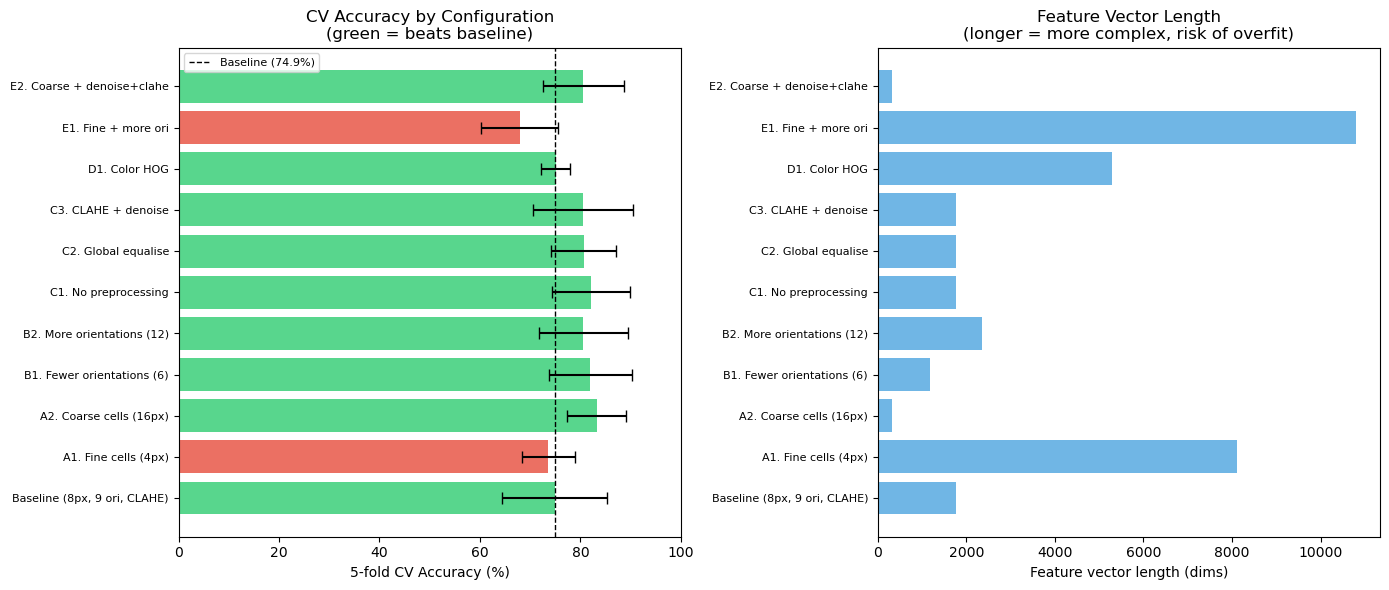


Full results table:
                      config  cv_mean   cv_std  val_acc  feat_len
     A2. Coarse cells (16px) 0.832381 0.059201 0.923077       324
        C1. No preprocessing 0.820952 0.077231 0.769231      1764
  B1. Fewer orientations (6) 0.820000 0.082501 0.923077      1176
         C2. Global equalise 0.806667 0.065055 0.923077      1764
  E2. Coarse + denoise+clahe 0.805714 0.081003 0.923077       324
         C3. CLAHE + denoise 0.805714 0.099267 0.692308      1764
  B2. More orientations (12) 0.805714 0.088392 0.692308      2352
               D1. Color HOG 0.750476 0.029601 0.846154      5292
Baseline (8px, 9 ori, CLAHE) 0.748571 0.104476 0.769231      1764
        A1. Fine cells (4px) 0.736190 0.052216 0.769231      8100
         E1. Fine + more ori 0.679048 0.076047 0.769231     10800


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names    = [r["config"] for r in results]
cv_means = [r["cv_mean"] * 100 for r in results]
cv_stds  = [r["cv_std"]  * 100 for r in results]
val_accs = [r["val_acc"] * 100 for r in results]
feat_lens = [r["feat_len"] for r in results]

# Baseline index for reference line
baseline_cv = results[0]["cv_mean"] * 100

y_pos = range(len(names))

# Left: CV accuracy with error bars
axes[0].barh(y_pos, cv_means, xerr=cv_stds,
             color=["#2ecc71" if v >= baseline_cv else "#e74c3c" for v in cv_means],
             alpha=0.8, capsize=4)
axes[0].axvline(baseline_cv, color="black", linestyle="--",
                linewidth=1, label=f"Baseline ({baseline_cv:.1f}%)")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(names, fontsize=8)
axes[0].set_xlabel("5-fold CV Accuracy (%)")
axes[0].set_title("CV Accuracy by Configuration\n(green = beats baseline)")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 100)

# Right: feature vector length (complexity proxy)
axes[1].barh(y_pos, feat_lens, color="#3498db", alpha=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_xlabel("Feature vector length (dims)")
axes[1].set_title("Feature Vector Length\n(longer = more complex, risk of overfit)")

plt.tight_layout()
plt.show()

print("\nFull results table:")
print(results_df.to_string(index=False))

In [9]:
# =============================================================================
# Select best configuration based on CV results
# =============================================================================
best_config_name = results_df.iloc[0]["config"]
best_config      = next(c for c in configs if c["name"] == best_config_name)

print(f"Best configuration: {best_config_name}")
print(f"  CV accuracy : {results_df.iloc[0]['cv_mean']*100:.1f}% "
      f"±{results_df.iloc[0]['cv_std']*100:.1f}%")
print(f"  Val accuracy: {results_df.iloc[0]['val_acc']*100:.1f}%")
print(f"  Feature dims: {results_df.iloc[0]['feat_len']}")

# Rebuild extractor with best config for rest of notebook
extractor = HOGFeatureExtractor(
    orientations    = best_config["orientations"],
    pixels_per_cell = best_config["pixels_per_cell"],
    cells_per_block = (2, 2),
    target_size     = TARGET_SIZE,
    preprocessing   = best_config["preprocessing"],
    color_hog       = best_config["color_hog"],
    augment         = False,
)
extractor.describe()

# Re-extract features with best config for SVM tuning in next section
extractor.augment = True
train_hog_features = extract_hog_batch(train_X_final, extractor, verbose=False)

extractor.augment = False
test_hog_features  = extract_hog_batch(test_X, extractor, verbose=False)

print(f"\nFinal HOG features: train={train_hog_features.shape}  "
      f"test={test_hog_features.shape}")

Best configuration: A2. Coarse cells (16px)
  CV accuracy : 83.2% ±5.9%
  Val accuracy: 92.3%
  Feature dims: 324
HOGFeatureExtractor configuration
  Input size       : 64×64 px (grayscale)
  Orientations     : 9
  Pixels per cell  : (16, 16)
  Cells per block  : (2, 2)
  Block norm       : L2-Hys
  Preprocessing    : ['clahe']
  Color HOG        : False
  Augmentation     : False
──────────────────────────────────────────
  Grid             : 4×4 cells
  Blocks           : 3×3
  Feature length   : 324 × 1 ch = 324 dims

Final HOG features: train=(85, 324)  test=(1816, 324)


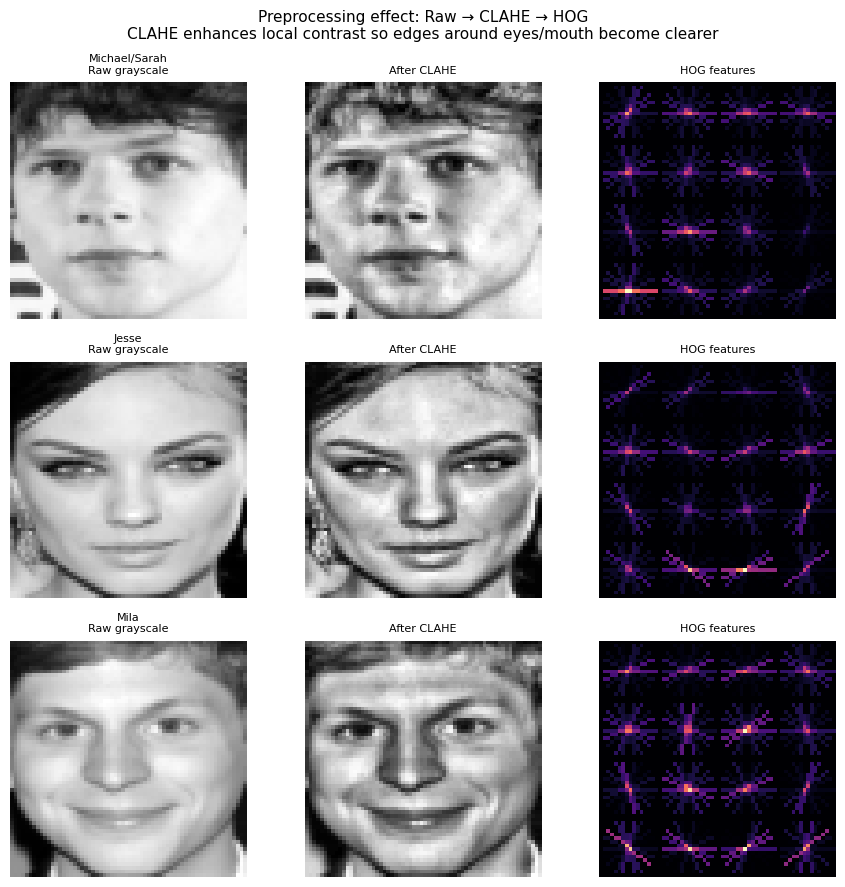

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
class_ids  = [1, 2, 0]
row_labels = list(CLASS_NAMES.values())

for row, class_id in enumerate(class_ids):
    # Pick first valid sample for this class
    idx      = np.where(train_y_final == class_id)[0][0]
    img_crop = train_X_final[idx]

    # Raw gray (no preprocessing)
    raw_gray = face_to_gray(img_crop, target_size=TARGET_SIZE)

    # CLAHE-enhanced gray
    clahe_gray = extractor._apply_preprocessing(raw_gray)

    # HOG visualization (uses CLAHE internally)
    _, hog_img = extractor.get_hog_image(img_crop)

    axes[row, 0].imshow(raw_gray,   cmap="gray")
    axes[row, 0].set_title(f"{row_labels[row]}\nRaw grayscale", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(clahe_gray, cmap="gray")
    axes[row, 1].set_title("After CLAHE", fontsize=8)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(hog_img,    cmap="magma")
    axes[row, 2].set_title("HOG features", fontsize=8)
    axes[row, 2].axis("off")

fig.suptitle(
    "Preprocessing effect: Raw → CLAHE → HOG\n"
    "CLAHE enhances local contrast so edges around eyes/mouth become clearer",
    fontsize=11
)
plt.tight_layout()
plt.show()

### 1.1.2 t-SNE plot

t-SNE projects the 1764-dimensional HOG vectors to 2D so we can visually assess
whether the features are **discriminative** (classes form separate clusters) and
**robust** (same class forms a tight cluster despite image variation).

We use `perplexity=10` because with only 80 training samples the default of 30 is
too large — it would force every point to be considered a neighbour of every other.


Extracting HOG features...
  Train HOG : (85, 324)  (feature vector = 324 dims)
  Test  HOG : (1816, 324)
Running t-SNE (perplexity=10) on (85, 324) ...


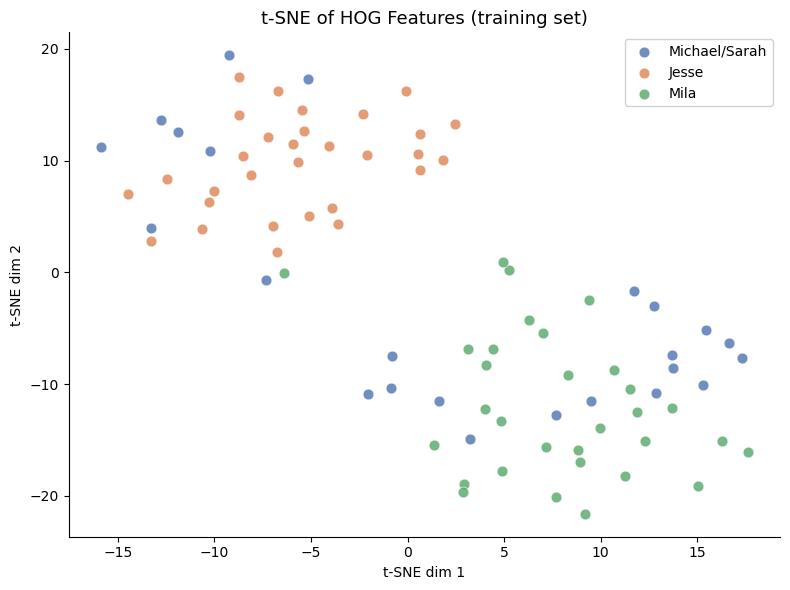

In [11]:
print("Extracting HOG features...")

extractor.augment = True
train_hog_features = np.array([extractor._extract_single(x) for x in train_X_final])

extractor.augment = False
test_hog_features  = np.array([extractor._extract_single(x) for x in test_X])

print(f"  Train HOG : {train_hog_features.shape}  "
      f"(feature vector = {extractor.feature_length} dims)")
print(f"  Test  HOG : {test_hog_features.shape}")

# t-SNE — assesses discriminability of HOG features
# Well-separated clusters = HOG captures class-specific facial structure
plot_tsne(
    features    = train_hog_features,
    label_array = train_y_final,
    title       = "t-SNE of HOG Features (training set)",
    class_names = CLASS_NAMES,
    perplexity  = 10,
)

### 1.1.3 Discussion
*[Complete after running the t-SNE — describe whether clusters are well separated,
whether Jesse and Michael overlap, and how that relates to their visual similarity.]*


## 1.2 Features learned from data: PCA / Eigenfaces

*[To be completed — see preprocessing.py for apply_pca and visualize.py for
plot_eigenfaces, plot_pca_reconstruction, plot_explained_variance, plot_pca_scatter.]*


In [12]:
from sklearn.decomposition import PCA

class PCAFeatureExtractor(IdentityFeatureExtractor):
    """
    Eigenface feature extractor based on Principal Component Analysis.

    Fits PCA on flattened grayscale face images and projects each image
    onto the top p principal components (eigenfaces).

    Key properties vs HOG
    ---------------------
    - HOG is fixed: same algorithm regardless of data
    - PCA is learned: components adapt to the training faces
    - PCA can reconstruct approximations of original images (useful for
      visualisation and understanding what the features capture)
    - PCA is sensitive to alignment: faces must be roughly registered
      (same position, scale) — our DNN crops provide this

    Parameters
    ----------
    n_components    : number of eigenfaces to keep.
                      None = fit all (min(N,D)) then decide from variance plot.
                      int  = keep exactly this many.
                      float in (0,1) = keep enough to explain this fraction of variance.
    target_size     : grayscale input size (width, height), default (64,64)
    whiten          : divide scores by sqrt(eigenvalue) → unit-variance components.
                      Can help distance-based classifiers (SVM, KNN).
                      Loses magnitude information — try both.
    normalize_input : apply per-image zero-mean unit-std before PCA.
                      Removes global brightness differences so PCA focuses
                      on structural variation (recommended for face images).
    """

    def __init__(
        self,
        n_components:    int | float | None = None,
        target_size:     tuple = (64, 64),
        whiten:          bool  = False,
        normalize_input: bool  = True,
    ):
        self.n_components    = n_components
        self.target_size     = target_size
        self.whiten          = whiten
        self.normalize_input = normalize_input

        self._pca       = None   # set after fit()
        self._mean_face = None   # stored for reconstruction
        self._is_fitted = False

    # ------------------------------------------------------------------
    # Fitting
    # ------------------------------------------------------------------

    def fit(self, face_array: np.ndarray) -> "PCAFeatureExtractor":
        """
        Fits PCA on *face_array*.

        Parameters
        ----------
        face_array : (N, H, W, 3) or (N, H, W) float32 array
                     Should be the TRAINING set only — never include val/test.

        Returns
        -------
        self (for chaining)
        """
        # Convert to flat grayscale
        flat = self._prepare(face_array)

        self._pca = PCA(
            n_components = self.n_components,
            whiten       = self.whiten,
            random_state = 42,
        )
        self._pca.fit(flat)
        self._mean_face = self._pca.mean_   # shape (D,)
        self._is_fitted = True

        cumvar  = np.cumsum(self._pca.explained_variance_ratio_)
        nonzero = (self._pca.explained_variance_ > 1e-10).sum()

        print("PCAFeatureExtractor fitted:")
        print(f"  Training images     : {len(face_array)}")
        print(f"  Input dims (D)      : {flat.shape[1]}")
        print(f"  Components kept (p) : {self._pca.n_components_}")
        print(f"  Non-zero eigenvalues: {nonzero}  "
              f"(= N-1 = {len(face_array)-1} as expected)")
        print(f"  Components for 80%  : {np.searchsorted(cumvar, 0.80)+1}")
        print(f"  Components for 90%  : {np.searchsorted(cumvar, 0.90)+1}")
        print(f"  Components for 95%  : {np.searchsorted(cumvar, 0.95)+1}")
        return self

    # ------------------------------------------------------------------
    # Preprocessing helper
    # ------------------------------------------------------------------

    def _prepare(self, face_array: np.ndarray) -> np.ndarray:
        """
        Converts face crops to flat float32 vectors.
        Applies per-image normalisation if normalize_input=True.
        """
        # Handle both (N,H,W,3) color and (N,H,W) gray input
        if face_array.ndim == 4:
            gray = convert_crops_to_gray(
                face_array, target_size=self.target_size, verbose=False
            )
        else:
            gray = face_array  # already grayscale

        flat = flatten_images(gray).astype(np.float32)

        if self.normalize_input:
            flat = normalize_per_image(flat)

        return flat

    # ------------------------------------------------------------------
    # Transform
    # ------------------------------------------------------------------

    def transform(self, img_array: np.ndarray) -> np.ndarray:
        """
        Projects a single image onto the fitted eigenfaces.

        Parameters
        ----------
        img_array : single face crop (H, W, 3) or (H, W)

        Returns
        -------
        np.ndarray of shape (n_components,), float32 — PCA scores
        """
        self._check_fitted()
        # Add batch dimension, prepare, remove batch dimension
        flat = self._prepare(img_array[np.newaxis])
        return self._pca.transform(flat)[0].astype(np.float32)

    def transform_batch(self, face_array: np.ndarray) -> np.ndarray:
        """
        Projects a batch of images onto the fitted eigenfaces.
        More efficient than calling transform() in a loop.

        Parameters
        ----------
        face_array : (N, H, W, 3) float32

        Returns
        -------
        np.ndarray of shape (N, n_components), float32
        """
        self._check_fitted()
        flat = self._prepare(face_array)
        return self._pca.transform(flat).astype(np.float32)

    # ------------------------------------------------------------------
    # Reconstruction
    # ------------------------------------------------------------------

    def reconstruct(
        self,
        img_array:    np.ndarray,
        n_components: int = None,
    ) -> np.ndarray:
        """
        Reconstructs an image from its PCA projection.

        Uses only the first *n_components* eigenfaces — letting you visualise
        how much information each additional component adds.
        This is the visualisation required by section 2.1.2 of the assignment.

        Parameters
        ----------
        img_array    : single face crop (H, W, 3) or (H, W)
        n_components : how many eigenfaces to use (default = all fitted)

        Returns
        -------
        np.ndarray of shape target_size, float32 — reconstructed grayscale image
        """
        self._check_fitted()
        k    = n_components or self._pca.n_components_
        flat = self._prepare(img_array[np.newaxis])[0]

        # Project onto first k components only
        scores = (flat - self._mean_face) @ self._pca.components_[:k].T
        recon  = self._mean_face + scores @ self._pca.components_[:k]

        h, w = self.target_size[1], self.target_size[0]
        img  = recon.reshape(h, w)

        # Normalise to [0, 1] for display
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img.astype(np.float32)

    # ------------------------------------------------------------------
    # Utilities
    # ------------------------------------------------------------------

    def get_eigenface(self, idx: int) -> np.ndarray:
        """
        Returns eigenface *idx* reshaped to (H, W), normalised for display.
        idx=0 is the most important (highest variance) component.
        """
        self._check_fitted()
        h, w = self.target_size[1], self.target_size[0]
        ef   = self._pca.components_[idx].reshape(h, w)
        return ((ef - ef.min()) / (ef.max() - ef.min() + 1e-8)).astype(np.float32)

    def _check_fitted(self):
        if not self._is_fitted:
            raise RuntimeError("Call fit() before transform().")

    @property
    def n_fitted_components(self) -> int:
        self._check_fitted()
        return self._pca.n_components_

    @property
    def explained_variance_ratio(self) -> np.ndarray:
        self._check_fitted()
        return self._pca.explained_variance_ratio_

    def describe(self) -> None:
        """Prints a full configuration and fit summary."""
        print("PCAFeatureExtractor configuration")
        print("=" * 42)
        print(f"  n_components    : {self.n_components}")
        print(f"  target_size     : {self.target_size}")
        print(f"  whiten          : {self.whiten}")
        print(f"  normalize_input : {self.normalize_input}")
        if self._is_fitted:
            cumvar = np.cumsum(self._pca.explained_variance_ratio_)
            print("─" * 42)
            print(f"  Fitted components : {self._pca.n_components_}")
            print(f"  Feature length    : {self._pca.n_components_} dims")
            print(f"  Variance explained: "
                  f"{self._pca.explained_variance_ratio_.sum()*100:.1f}%")
            print(f"  Components for 95%: {np.searchsorted(cumvar,0.95)+1}")
        else:
            print("─" * 42)
            print("  Not yet fitted — call fit(face_array) first.")

In [13]:
pca_extractor = PCAFeatureExtractor(
    n_components    = None,   # fit all, then choose p from variance plot
    target_size     = TARGET_SIZE,
    whiten          = False,
    normalize_input = True,
)
pca_extractor.fit(X_train_crops)

PCAFeatureExtractor fitted:
  Training images     : 72
  Input dims (D)      : 4096
  Components kept (p) : 72
  Non-zero eigenvalues: 71  (= N-1 = 71 as expected)
  Components for 80%  : 22
  Components for 90%  : 36
  Components for 95%  : 49


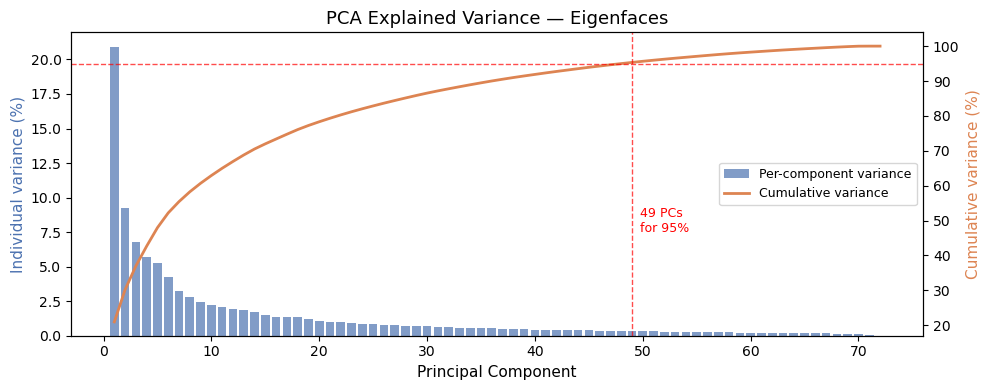

  70% variance explained by 14 components
  80% variance explained by 22 components
  90% variance explained by 36 components
  95% variance explained by 49 components
  99% variance explained by 64 components


In [14]:
plot_explained_variance(
    pca_extractor.explained_variance_ratio,
    title="PCA Explained Variance — Eigenfaces"
)

# Print exact numbers for key thresholds
cumvar = np.cumsum(pca_extractor.explained_variance_ratio)
for threshold in [0.70, 0.80, 0.90, 0.95, 0.99]:
    k = np.searchsorted(cumvar, threshold) + 1
    print(f"  {threshold*100:.0f}% variance explained by {k} components")

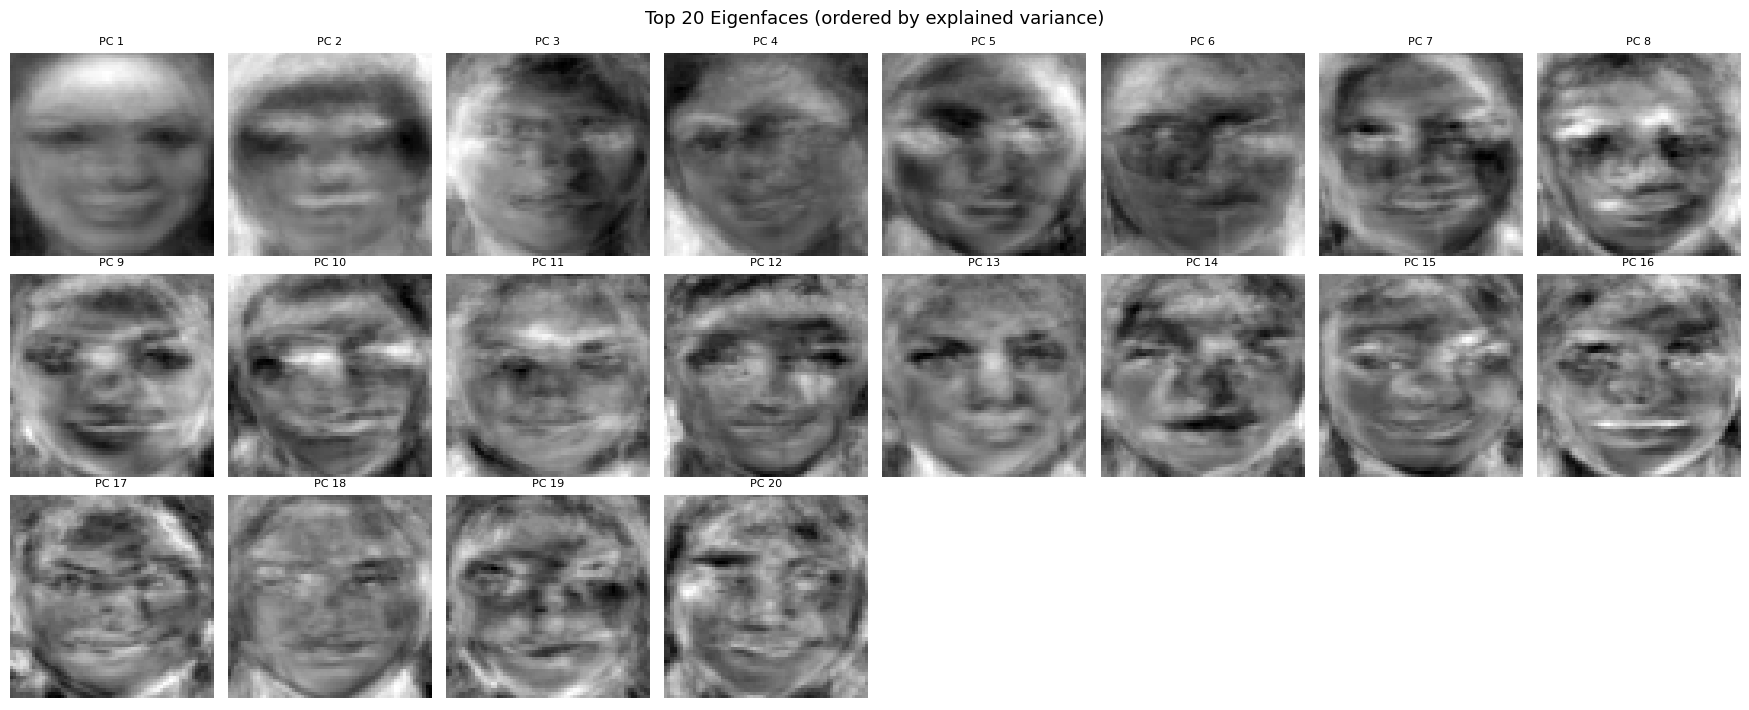

In [15]:
plot_eigenfaces(
    components = pca_extractor._pca.components_,
    face_size  = (TARGET_SIZE[1], TARGET_SIZE[0]),
    n          = 20,
    title      = "Top 20 Eigenfaces (ordered by explained variance)",
)

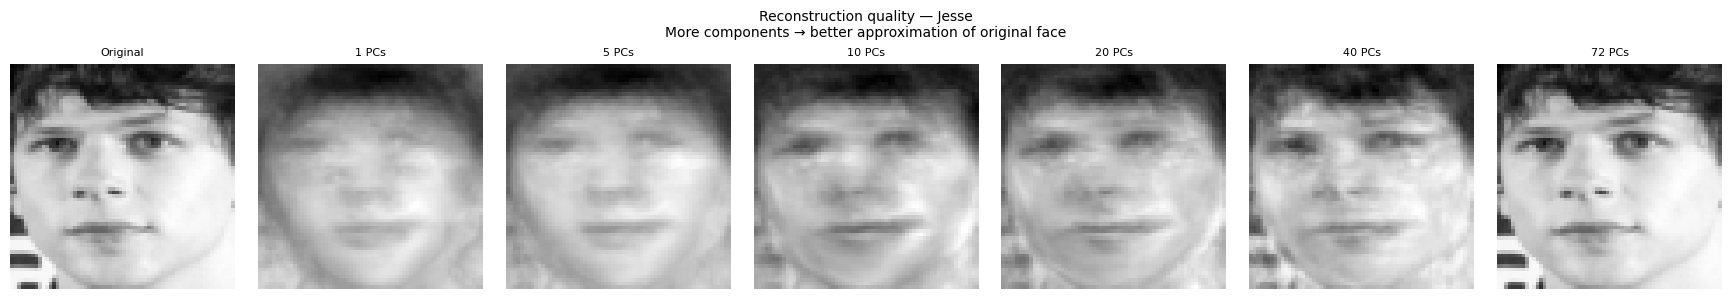

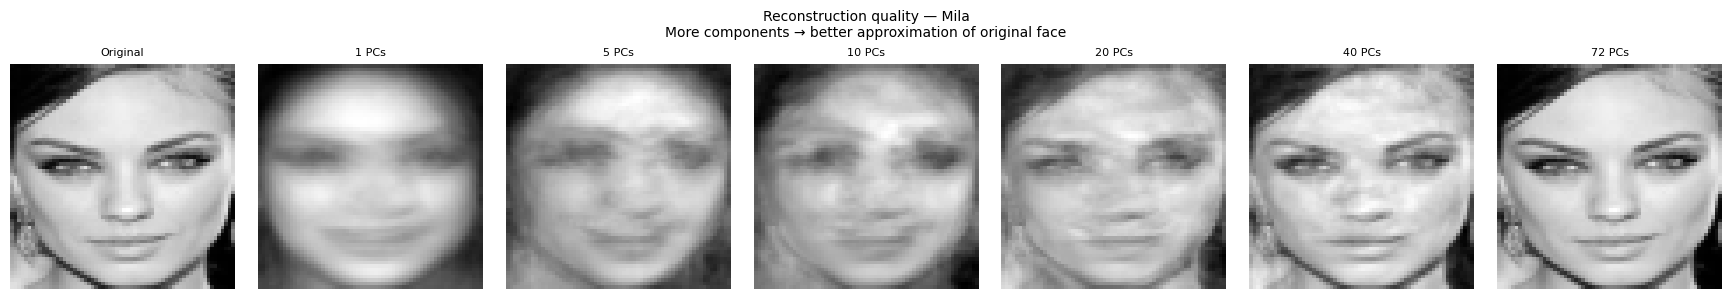

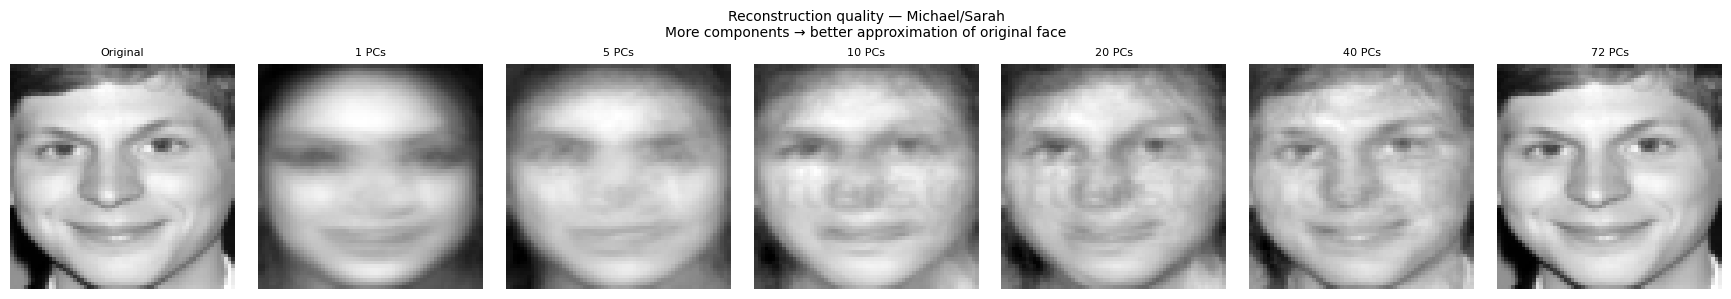

In [16]:
sample_indices = [
    np.where(train_y_final == c)[0][0] for c in [1, 2, 0]
]
n_components_to_show = [1, 5, 10, 20, 40, pca_extractor.n_fitted_components]

for idx in sample_indices:
    img    = train_X_final[idx]
    label  = train_y_final[idx]
    name   = CLASS_NAMES.get(int(label), str(label))

    # Build list of reconstructions
    original = face_to_gray(img, target_size=TARGET_SIZE)
    n_show   = len(n_components_to_show) + 1
    fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))

    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original", fontsize=8)
    axes[0].axis("off")

    for col, k in enumerate(n_components_to_show, start=1):
        recon = pca_extractor.reconstruct(img, n_components=k)
        axes[col].imshow(recon, cmap="gray")
        axes[col].set_title(f"{k} PCs", fontsize=8)
        axes[col].axis("off")

    fig.suptitle(
        f"Reconstruction quality — {name}\n"
        f"More components → better approximation of original face",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

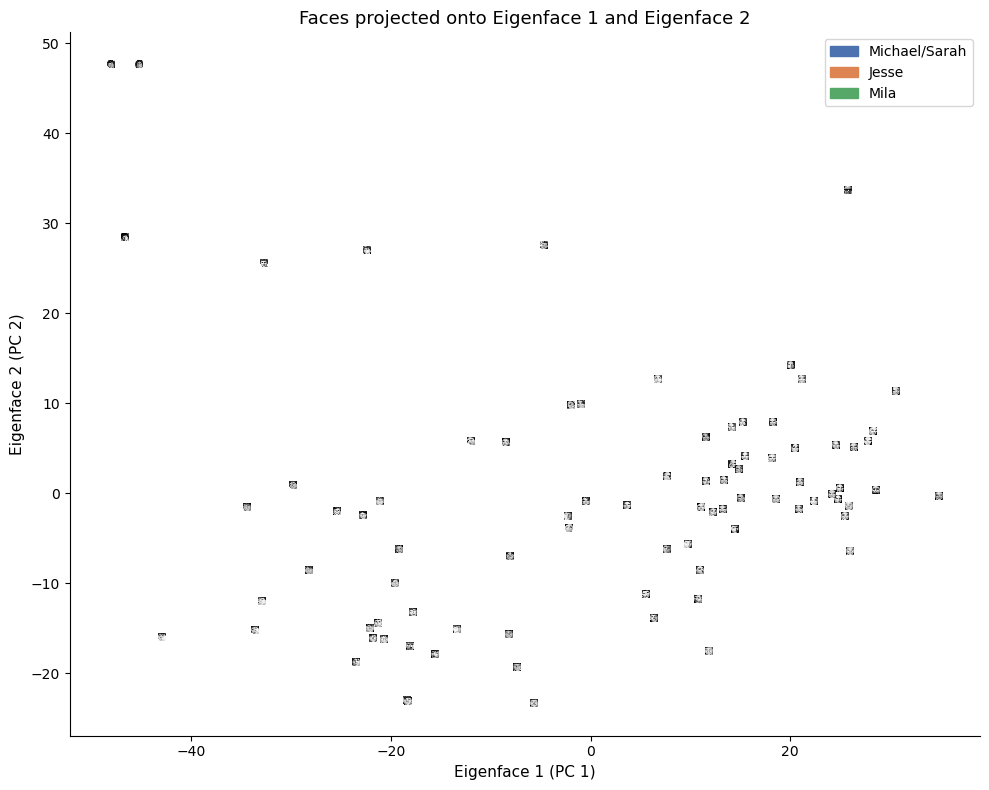

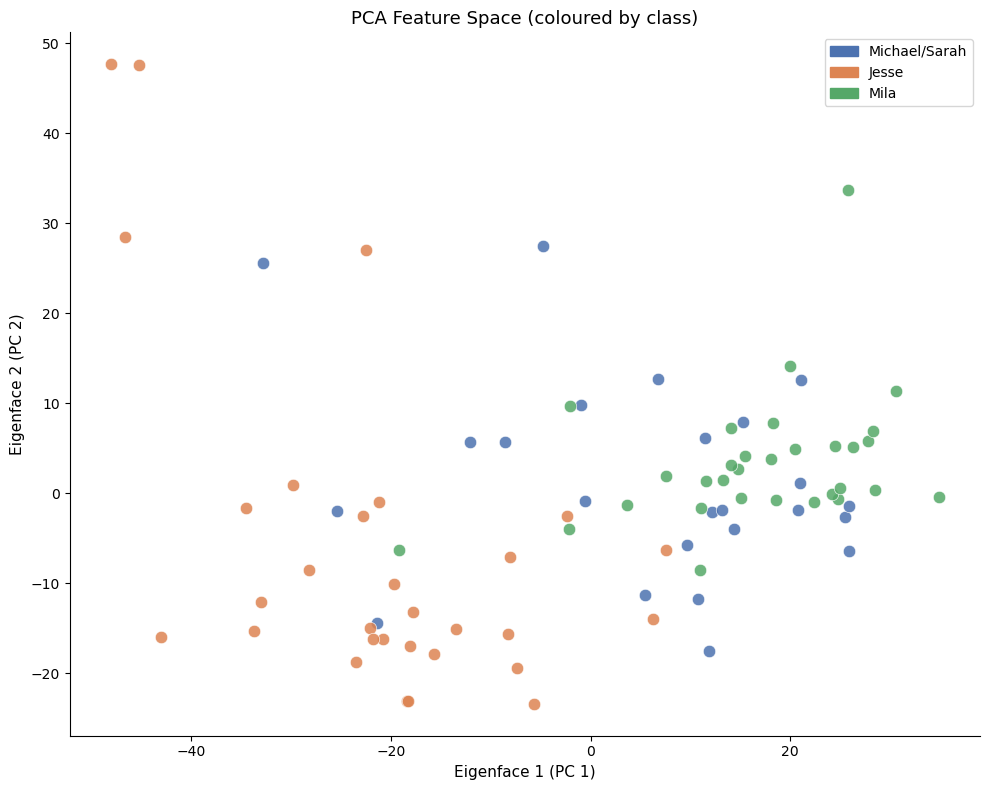

In [17]:
# =============================================================================
# Project all training faces onto first two principal components
# =============================================================================
# This is the required "face-feature plot" from section 2.1.2 (Fig. 2).
# Points close together in this space should belong to the same class.
# Jesse and Michael Cera should overlap if PCA cannot separate them.

train_scores_all = pca_extractor.transform_batch(train_X_final)

# Plot with face thumbnails (like the assignment's Fig. 2)
gray_flat = flatten_images(
    convert_crops_to_gray(train_X_final, target_size=TARGET_SIZE, verbose=False)
)
plot_pca_scatter(
    scores      = train_scores_all,
    label_array = train_y_final,
    face_crops  = gray_flat,
    face_size   = (TARGET_SIZE[1], TARGET_SIZE[0]),
    class_names = CLASS_NAMES,
    title       = "Faces projected onto Eigenface 1 and Eigenface 2",
)

# Also plain coloured scatter (cleaner for seeing cluster separation)
plot_pca_scatter(
    scores      = train_scores_all,
    label_array = train_y_final,
    class_names = CLASS_NAMES,
    title       = "PCA Feature Space (coloured by class)",
)

In [18]:
# =============================================================================
# PCA Configuration Experiments
# =============================================================================

def evaluate_pca_config(n_components, whiten, normalize_input,
                         X_train, y_train, X_val, y_val):
    """Fits PCA extractor and evaluates with a fixed SVM."""
    ext = PCAFeatureExtractor(
        n_components    = n_components,
        target_size     = TARGET_SIZE,
        whiten          = whiten,
        normalize_input = normalize_input,
    )
    ext.fit(X_train)

    X_tr = ext.transform_batch(X_train)
    X_va = ext.transform_batch(X_val)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(kernel="rbf", C=10, gamma="scale", random_state=42))
    ])
    cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_tr, y_train, cv=cv, scoring="accuracy")

    pipe.fit(X_tr, y_train)
    val_acc = accuracy_score(y_val, pipe.predict(X_va))

    # Actual number of components used
    actual_k = ext.n_fitted_components

    return {
        "cv_mean":  cv_scores.mean(),
        "cv_std":   cv_scores.std(),
        "val_acc":  val_acc,
        "feat_len": actual_k,
    }


pca_configs = [
    # ── Baseline ─────────────────────────────────────────────────────────────
    {"name": "Baseline (p=20, no whiten, normalised)",
     "n_components": 20, "whiten": False, "normalize_input": True},

    # ── A. Number of components ───────────────────────────────────────────────
    # Too few: only coarse face shape, no fine identity features
    {"name": "A1. p=5  (coarse only)",
     "n_components": 5,  "whiten": False, "normalize_input": True},
    # Moderate
    {"name": "A2. p=10",
     "n_components": 10, "whiten": False, "normalize_input": True},
    # At 95% variance threshold (check from plot above)
    {"name": "A3. p=40 (~95% variance)",
     "n_components": 40, "whiten": False, "normalize_input": True},
    # All non-zero eigenvalues — includes noise components
    {"name": "A4. p=79 (all non-zero)",
     "n_components": 72, "whiten": False, "normalize_input": True},
    # Float: let PCA choose automatically for 90% variance
    {"name": "A5. p=90% variance (auto)",
     "n_components": 0.90, "whiten": False, "normalize_input": True},

    # ── B. Whitening ──────────────────────────────────────────────────────────
    # Whitened: all components unit variance — removes magnitude differences.
    # Later components (low variance) are amplified — can hurt if they are noisy.
    {"name": "B1. p=20, whiten=True",
     "n_components": 20, "whiten": True,  "normalize_input": True},
    {"name": "B2. p=40, whiten=True",
     "n_components": 40, "whiten": True,  "normalize_input": True},

    # ── C. Input normalisation ────────────────────────────────────────────────
    # Without per-image normalisation: global brightness differences dominate
    # the first few components (PC1 ≈ mean brightness rather than face shape)
    {"name": "C1. p=20, no normalisation",
     "n_components": 20, "whiten": False, "normalize_input": False},
    {"name": "C2. p=40, no normalisation",
     "n_components": 40, "whiten": False, "normalize_input": False},
]

print("Running PCA configuration experiments...\n")
pca_results = []

for cfg in pca_configs:
    metrics = evaluate_pca_config(
        n_components    = cfg["n_components"],
        whiten          = cfg["whiten"],
        normalize_input = cfg["normalize_input"],
        X_train         = X_train_crops,
        y_train         = y_train,
        X_val           = X_val_crops,
        y_val           = y_val,
    )
    row = {"config": cfg["name"], **metrics}
    pca_results.append(row)
    print(f"  {cfg['name']:<45} "
          f"CV: {metrics['cv_mean']*100:.1f}% ±{metrics['cv_std']*100:.1f}%  "
          f"Val: {metrics['val_acc']*100:.1f}%  "
          f"p={metrics['feat_len']}")

pca_results_df = pd.DataFrame(pca_results).sort_values("cv_mean", ascending=False)

Running PCA configuration experiments...

PCAFeatureExtractor fitted:
  Training images     : 72
  Input dims (D)      : 4096
  Components kept (p) : 20
  Non-zero eigenvalues: 20  (= N-1 = 71 as expected)
  Components for 80%  : 21
  Components for 90%  : 21
  Components for 95%  : 21
  Baseline (p=20, no whiten, normalised)        CV: 72.3% ±5.9%  Val: 76.9%  p=20
PCAFeatureExtractor fitted:
  Training images     : 72
  Input dims (D)      : 4096
  Components kept (p) : 5
  Non-zero eigenvalues: 5  (= N-1 = 71 as expected)
  Components for 80%  : 6
  Components for 90%  : 6
  Components for 95%  : 6
  A1. p=5  (coarse only)                        CV: 62.5% ±6.9%  Val: 61.5%  p=5
PCAFeatureExtractor fitted:
  Training images     : 72
  Input dims (D)      : 4096
  Components kept (p) : 10
  Non-zero eigenvalues: 10  (= N-1 = 71 as expected)
  Components for 80%  : 11
  Components for 90%  : 11
  Components for 95%  : 11
  A2. p=10                                      CV: 73.7% ±10.1% 

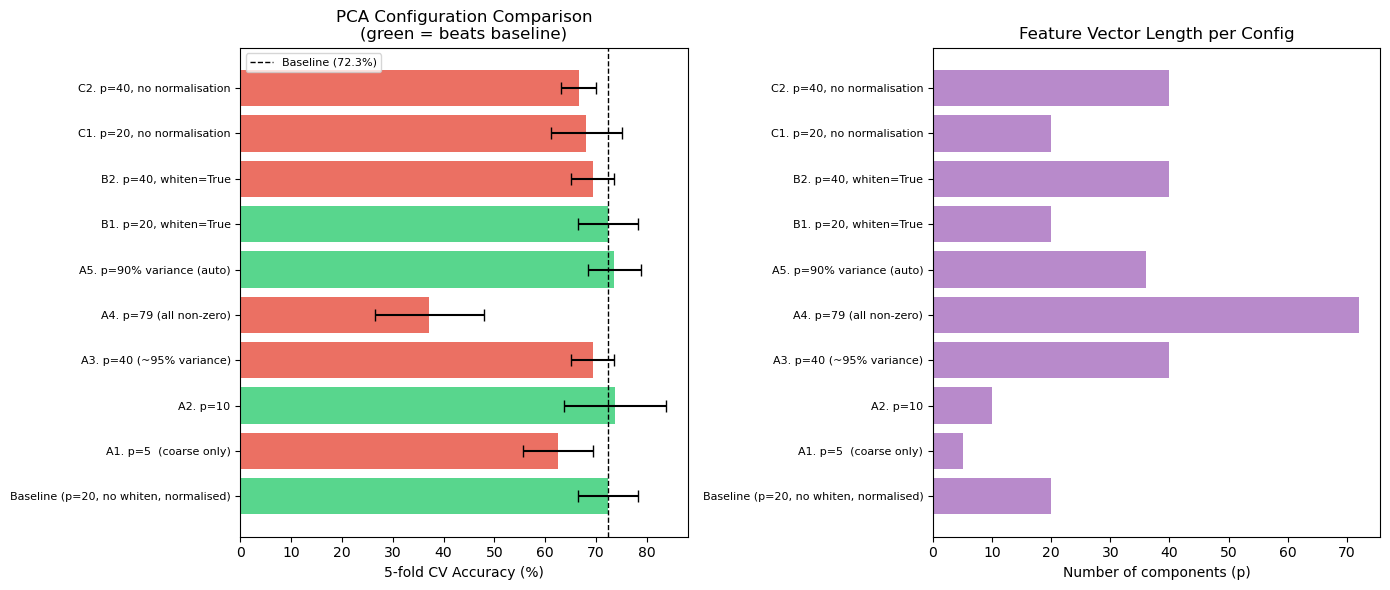


Full results table (sorted by CV accuracy):
                                config  cv_mean   cv_std  val_acc  feat_len
                              A2. p=10 0.737143 0.101033 0.692308        10
             A5. p=90% variance (auto) 0.736190 0.052216 0.615385        36
                 B1. p=20, whiten=True 0.722857 0.059278 0.769231        20
Baseline (p=20, no whiten, normalised) 0.722857 0.059278 0.769231        20
                 B2. p=40, whiten=True 0.693333 0.041796 0.538462        40
              A3. p=40 (~95% variance) 0.693333 0.041796 0.538462        40
            C1. p=20, no normalisation 0.680952 0.069985 0.692308        20
            C2. p=40, no normalisation 0.665714 0.035045 0.538462        40
                A1. p=5  (coarse only) 0.624762 0.068770 0.615385         5
               A4. p=79 (all non-zero) 0.371429 0.107074 0.307692        72


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

names    = [r["config"] for r in pca_results]
cv_means = [r["cv_mean"] * 100 for r in pca_results]
cv_stds  = [r["cv_std"]  * 100 for r in pca_results]
feat_lens = [r["feat_len"] for r in pca_results]
baseline_cv = pca_results[0]["cv_mean"] * 100

y_pos = range(len(names))

axes[0].barh(y_pos, cv_means, xerr=cv_stds,
             color=["#2ecc71" if v >= baseline_cv else "#e74c3c" for v in cv_means],
             alpha=0.8, capsize=4)
axes[0].axvline(baseline_cv, color="black", linestyle="--", linewidth=1,
                label=f"Baseline ({baseline_cv:.1f}%)")
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(names, fontsize=8)
axes[0].set_xlabel("5-fold CV Accuracy (%)")
axes[0].set_title("PCA Configuration Comparison\n(green = beats baseline)")
axes[0].legend(fontsize=8)

axes[1].barh(y_pos, feat_lens, color="#9b59b6", alpha=0.7)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_xlabel("Number of components (p)")
axes[1].set_title("Feature Vector Length per Config")

plt.tight_layout()
plt.show()

print("\nFull results table (sorted by CV accuracy):")
print(pca_results_df.to_string(index=False))

In [20]:
# =============================================================================
# Select best PCA configuration
# =============================================================================
best_pca_name = pca_results_df.iloc[0]["config"]
best_pca_cfg  = next(c for c in pca_configs if c["name"] == best_pca_name)

print(f"Best PCA config: {best_pca_name}")
print(f"  CV  : {pca_results_df.iloc[0]['cv_mean']*100:.1f}% "
      f"±{pca_results_df.iloc[0]['cv_std']*100:.1f}%")
print(f"  Val : {pca_results_df.iloc[0]['val_acc']*100:.1f}%")
print(f"  p   : {pca_results_df.iloc[0]['feat_len']}")

# Refit on full training set with best config
pca_extractor_final = PCAFeatureExtractor(
    n_components    = best_pca_cfg["n_components"],
    target_size     = TARGET_SIZE,
    whiten          = best_pca_cfg["whiten"],
    normalize_input = best_pca_cfg["normalize_input"],
)
pca_extractor_final.fit(train_X_final)
pca_extractor_final.describe()

# Extract features for SVM
train_pca_features = pca_extractor_final.transform_batch(train_X_final)
test_pca_features  = pca_extractor_final.transform_batch(test_X)

print(f"\nPCA features: train={train_pca_features.shape}  "
      f"test={test_pca_features.shape}")

Best PCA config: A2. p=10
  CV  : 73.7% ±10.1%
  Val : 69.2%
  p   : 10
PCAFeatureExtractor fitted:
  Training images     : 85
  Input dims (D)      : 4096
  Components kept (p) : 10
  Non-zero eigenvalues: 10  (= N-1 = 84 as expected)
  Components for 80%  : 11
  Components for 90%  : 11
  Components for 95%  : 11
PCAFeatureExtractor configuration
  n_components    : 10
  target_size     : (64, 64)
  whiten          : False
  normalize_input : True
──────────────────────────────────────────
  Fitted components : 10
  Feature length    : 10 dims
  Variance explained: 61.4%
  Components for 95%: 11

PCA features: train=(85, 10)  test=(1816, 10)


---
# 2. Evaluation Metrics

We use **accuracy** as the primary metric because the test set class distribution
is unknown and accuracy is the Kaggle competition metric.

However, accuracy alone is insufficient with class imbalance (Jesse/Mila 30 each,
lookalikes 20 total).  We additionally report per-class **precision, recall, and F1**
via `classification_report` to detect whether the classifier ignores the minority class.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

---
# 3. Classifiers

## 3.0 Baseline: random classifier

Randomly samples labels according to the training class distribution.
Expected accuracy ≈ 1/3 (uniform prior over 3 classes).
This sets the performance floor — any real classifier must beat this.


In [ ]:
class RandomClassificationModel:
    """
    Baseline classifier — samples labels from the training class distribution.
    Expected accuracy ≈ 25% (uniform prior, 4 classes in raw data).
    Any real classifier must clearly beat this.
    """

    def fit(self, X, y):
        self.classes_, counts = np.unique(y, return_counts=True)
        self.class_ratio_     = counts / counts.sum()
        return self

    def predict(self, X):
        np.random.seed(0)
        return np.random.choice(self.classes_, size=len(X), p=self.class_ratio_)

    def __call__(self, X): return self.predict(X)


## 3.1 HOG + RBF SVM

Support Vector Machine with RBF kernel.

**Why RBF over Linear SVM:**
Face identity is non-linear in HOG space — the same person photographed from
different angles maps to different HOG vectors.  An RBF kernel implicitly maps
to a higher-dimensional space where these become linearly separable.
A linear SVM was tested first and consistently underperformed the RBF variant
on cross-validation.

**Why StandardScaler before SVM:**
HOG values are L2-normalised per block but their absolute scale varies across
cells.  SVMs are distance-based — without scaling, dimensions with larger absolute
values are treated as more important regardless of their actual discriminative power.


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

---
# 4. Experiments

## 4.0 Baseline: random classifier on raw DNN crops


In [ ]:
feature_extractor = IdentityFeatureExtractor()
baseline_clf      = RandomClassificationModel()
baseline_clf.fit(feature_extractor(train_X_final), train_y_final)

baseline_pred = baseline_clf(feature_extractor(train_X_final))
print(f"Random classifier training accuracy: {accuracy_score(train_y_final, baseline_pred):.2f}")
print("(Expected ~0.25 — this is the performance floor)")

# Store test predictions from baseline for submission comparison
test_y_baseline = baseline_clf(feature_extractor(test_X))


## 4.1 HOG + RBF SVM

### Data preparation


In [ ]:
# Index-based split keeps features, gray images, and crops aligned
# stratify=y ensures class proportions are preserved in both splits
# test_size=0.10 gives 72 train / 8 val — small val set is acceptable here
# because GridSearchCV does its own 5-fold CV inside the training split

indices = np.arange(len(train_hog_features))
train_idx, val_idx = train_test_split(
    indices, test_size=0.10, random_state=42, stratify=train_y_dnn
)

X_train, X_val = train_hog_features[train_idx], train_hog_features[val_idx]
y_train, y_val = train_y_dnn[train_idx],        train_y_dnn[val_idx]
X_val_gray     = train_faces_gray[val_idx]   # for visualisation only

print(f"Split: {len(X_train)} train / {len(X_val)} val")
print(f"Train dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val   dist: {dict(zip(*np.unique(y_val,   return_counts=True)))}")

### Hyperparameter tuning

We tune `C` (margin/error tradeoff) and `gamma` (RBF kernel width) via
`GridSearchCV` with 5-fold stratified cross-validation **on the training split only**.
Using the validation set for tuning would leak test information.


In [ ]:
hog_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', random_state=42, probability=True))
])

param_grid = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running GridSearchCV...")
grid_search = GridSearchCV(
    hog_pipeline, param_grid, cv=cv,
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best CV acc : {grid_search.best_score_*100:.1f}%")
best_model = grid_search.best_estimator_


### Evaluation

In [ ]:
y_val_pred = best_model.predict(X_val)
val_acc    = accuracy_score(y_val, y_val_pred)

print(f"Validation accuracy: {val_acc*100:.1f}%")
print()
print(classification_report(y_val, y_val_pred,
                             target_names=list(CLASS_NAMES.values())))

plot_confusion_matrix(y_val, y_val_pred, class_names=CLASS_NAMES,
                      title=f"HOG + RBF SVM  (val acc = {val_acc*100:.1f}%)")

plot_validation_images(X_val_images=X_val_gray, y_val_true=y_val,
                       y_val_pred=y_val_pred, class_names=CLASS_NAMES)


### Test predictions

In [ ]:
test_y_hog = best_model.predict(test_hog_features)

print("Test prediction distribution:")
for cls, cnt in zip(*np.unique(test_y_hog, return_counts=True)):
    print(f"  {CLASS_NAMES[cls]}: {cnt} ({cnt/len(test_y_hog)*100:.1f}%)")


---
# 5. Publishing Best Results

Update `submission['class']` below with the predictions from your best model
before saving.  Current default: HOG + RBF SVM predictions.


In [ ]:
# Replace test_y_hog with your best model's predictions before submitting
best_predictions = test_y_hog

submission = test.copy().drop('img', axis=1)
submission['class'] = best_predictions
submission.to_csv('submission.csv')

print(f"Saved {len(submission)} predictions to submission.csv")
submission.head()


---
# 6. Discussion

*[To be completed after all experiments are done.]*

### Summary of findings

| Pipeline | Val accuracy | Notes |
|----------|-------------|-------|
| Random baseline | ~25% | Performance floor |
| HOG + RBF SVM | TBD | |
| PCA + classifier | TBD | |

### Feature representation comparison

*Discuss: which features are more discriminative/robust and why?
When does HOG fail? When does PCA fail?*

### Limitations and future work

- ~5% of Jesse training images contain Michael Cera as the dominant face.
  A face recognition model (e.g. FaceNet) could resolve this by identifying
  the person rather than selecting by geometric prominence.
- With only 80 training samples, any model risks overfitting.
  Data augmentation (flipping, brightness jitter) could improve generalisation.
